# Cluster stats

The purpose of this notebook is to analyze `STATE x leiden cluster` matrices for each accession.

## Data preparation

The data were produced by [`pipelines/cluster_stats.py`](../pipelines/cluster_stats.py) in run [`cluster_stats/clustered_20260509`](../output/cluster_stats/clustered_20260509). All aformentioned matrices were written to [`cluster_stats.json`](../output/cluster_stats/clustered_20260509/cluster_stats.json)

## Imports

In [10]:
import numpy as np
import pandas as pd
import xarray as xr
from scipy import stats
import matplotlib.pyplot as plt

## Construct `xarray.DataArray` object

In [11]:
from shared.repo import REPO_ROOT
from pathlib import Path
import json

CLUSTER_STATS_PATH = (
    REPO_ROOT / "output/cluster_stats/clustered_20260509/cluster_stats.json"
)

with open(CLUSTER_STATS_PATH) as f:
    _data = json.load(f)

samples    = list(_data.keys())
cell_types = sorted({ct for s in _data.values() for ct in s.keys()})
clusters   = sorted(
    {cl for s in _data.values() for ct in s.values() for cl in ct.keys()},
    key=int,
)

arr = np.zeros((len(samples), len(cell_types), len(clusters)), dtype=np.int32)

for i, sample in enumerate(samples):
    for j, cell_type in enumerate(cell_types):
        for k, cluster in enumerate(clusters):
            arr[i, j, k] = _data[sample].get(cell_type, {}).get(cluster, 0)

da = xr.DataArray(
    arr,
    dims=["accession", "STATE", "leiden_cluster"],
    coords={"accession": samples, "STATE": cell_types, "leiden_cluster": clusters},
    name="cell_count",
)

da

<xarray.DataArray 'cell_count' (accession: 765, STATE: 39, leiden_cluster: 106)> Size: 13MB
array([[[    1,     0,     0, ...,     0,     0,     0],
        [    8,   267,     5, ...,     0,     0,     0],
        [ 3468,    10,   903, ...,     0,     0,     0],
        ...,
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0]],

       [[11474,   256,  9593, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        ...,
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0]],

       [[ 6609,  1837,  1609, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        ...,
...
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0]],

       [[    0,     0,     0, ...,     0,     0,     0],
        [   20,   316,   781, ...,     0,     0,     0],
        [  135,   894,   558, ...,     0,     0,     0],
        ...,
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0]],

       [[    0,     0,     0, ...,     0,     0,     0],
        [   86,   196,   191, ...,     0,     0,     0],
        [ 1675,  3196,   633, ...,     0,     0,     0],
        ...,
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0]]],
      shape=(765, 39, 106), dtype=int32)
Coordinates:
  * accession       (accession) <U11 34kB 'ERX11662338' ... 'SRX9927818'
  * STATE           (STATE) <U52 8kB '' 'B cell' ... 'vein endothelial cell'
  * leiden_cluster  (leiden_cluster) <U3 1kB '0' '1' '2' ... '103' '104' '105'

## Stats
### Compute metrics across leiden clusters
- Shannon entropy
- Normalized Shannon entropy = `Shannon entropy / log(n_states)`

In [12]:
def _shannon_entropy(counts, dim):
    """Shannon entropy (bits) of a counts DataArray along `dim`."""
    totals = counts.sum(dim)
    p = (counts / totals).where(totals > 0)
    h = -(p * np.log2(p.where(p > 0))).sum(dim)
    return h.where(totals > 0)


def _normalized_entropy(counts, dim):
    """Normalized Shannon entropy: H / log2(k), where k = non-zero categories."""
    h = _shannon_entropy(counts, dim)
    k = (counts > 0).sum(dim).astype(float)
    return xr.where(k > 1, h / np.log2(k.where(k > 0)), xr.where(k == 1, 0.0, np.nan))


def _kl_divergence(counts_p, counts_q, dim):
    """KL divergence D_KL(P || Q) in bits between two count DataArrays along `dim`.

    Decomposed as cross_entropy(P, Q) - H(P), where H(P) is Shannon entropy.
    Terms where P = 0 contribute 0. Terms where Q = 0 and P > 0 yield inf.
    Returns nan where either distribution has no observations.
    """
    totals_p = counts_p.sum(dim)
    totals_q = counts_q.sum(dim)
    p = (counts_p / totals_p).where(totals_p > 0)
    q = (counts_q / totals_q).where(totals_q > 0)
    cross_entropy = -(p.where(p > 0) * np.log2(q.where(q > 0))).sum(dim)
    kl = cross_entropy - _shannon_entropy(counts_p, dim)
    return kl.where((totals_p > 0) & (totals_q > 0))


ds = xr.Dataset({
    "cell_count": da
})

ds["n_cells_leiden"] = ds["cell_count"].sum(dim="STATE")
ds["n_cells_STATE"] = ds["cell_count"].sum(dim="leiden_cluster")
ds["nse_leiden"] = _normalized_entropy(ds["cell_count"], dim="STATE")
ds["nse_STATE"] = _normalized_entropy(ds["cell_count"], dim="leiden_cluster")

### Confirm that the distribution of leiden cluster sizes is lognormal

lognormal fit:  mu = 5.564,  sigma = 1.228  (loc fixed at 0)
KS test vs fitted lognormal:  D = 0.0241,  p = 6.6e-05


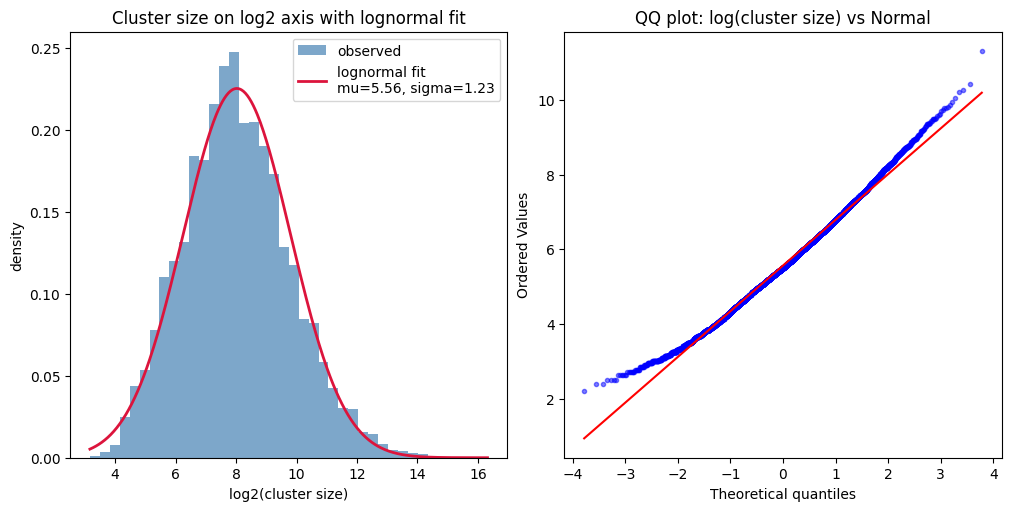

In [13]:
cluster_sizes = ds.n_cells_leiden.stack(point=("accession", "leiden_cluster"))
cluster_sizes = cluster_sizes.where(cluster_sizes > 0).dropna(dim="point")

sizes = cluster_sizes.values.astype(float)
log_sz = np.log2(sizes)

shape, loc, scale = stats.lognorm.fit(sizes, floc=0)
mu, sigma = np.log(scale), shape
print(f"lognormal fit:  mu = {mu:.3f},  sigma = {sigma:.3f}  (loc fixed at 0)")

ks_stat, ks_p = stats.kstest(sizes, "lognorm", args=(shape, loc, scale))
print(f"KS test vs fitted lognormal:  D = {ks_stat:.4f},  p = {ks_p:.3g}")

fig, (ax_hist, ax_qq) = plt.subplots(1, 2, figsize=(10, 5), layout="constrained")

ax_hist.hist(log_sz, bins=40, density=True, color="steelblue", alpha=0.7, label="observed")
xx = np.linspace(log_sz.min(), log_sz.max(), 400)
pdf_log = stats.norm.pdf(xx, loc=mu / np.log(2), scale=sigma / np.log(2))
ax_hist.plot(xx, pdf_log, color="crimson", lw=2, label=f"lognormal fit\nmu={mu:.2f}, sigma={sigma:.2f}")
ax_hist.set_xlabel("log2(cluster size)")
ax_hist.set_ylabel("density")
ax_hist.set_title("Cluster size on log2 axis with lognormal fit")
ax_hist.legend()

stats.probplot(np.log(sizes), dist="norm", plot=ax_qq)
ax_qq.set_title("QQ plot: log(cluster size) vs Normal")
ax_qq.get_lines()[0].set_markersize(3)
ax_qq.get_lines()[0].set_alpha(0.5)

plt.show()

## Plotting

### Distribution of entropy of leiden clusters across cluster size bins
ANOVA on bin means reported

one-way ANOVA: F = 86.9330,  p = 1.956e-55


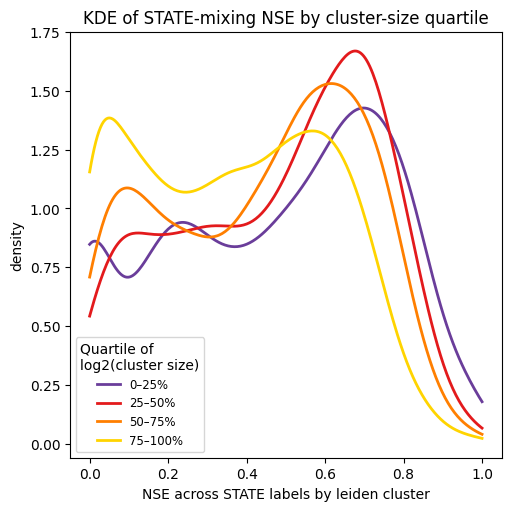

In [14]:
paired = xr.Dataset({
    "nse": ds.nse_leiden,
    "n_cells": ds.n_cells_leiden,
}).stack(point=("accession", "leiden_cluster")).dropna(dim="point")

nse_vals = paired["nse"].values
log_sz = np.log2(np.maximum(paired["n_cells"].values.astype(float), 1.0))

bins = pd.qcut(log_sz, q=4, duplicates="drop")
quartiles = ["0–25%", "25–50%", "50–75%", "75–100%"]
fig, ax = plt.subplots(1, 1, figsize=(5, 5), layout="constrained", sharex=True)

n_cats = len(bins.categories)
if n_cats == 4:
    palette = ["#6a3d9a", "#e31a1c", "#ff7f00", "#ffd400"]
else:
    palette = [plt.cm.plasma(t) for t in np.linspace(0.1, 0.9, max(n_cats, 1))]

bin_codes = np.asarray(bins.codes)
groups = []
labels = []
for idx, interval in enumerate(bins.categories):
    mask = bin_codes == idx
    sub = nse_vals[mask]
    sub = sub[np.isfinite(sub)]
    groups.append(sub)
    labels.append(f"[{interval.left:.1f}, {interval.right:.1f}]n={mask.sum():d}")

for idx, (sub, interval) in enumerate(zip(groups, bins.categories)):
    if sub.size < 2:
        continue
    kde = stats.gaussian_kde(sub)
    pad = max((sub.max() - sub.min()) * 0.08, 0.02)
    lo, hi = max(0.0, sub.min() - pad), min(1.0, sub.max() + pad)
    xx = np.linspace(lo, hi, 256)
    ax.plot(xx, kde(xx), color=palette[idx], lw=2,
             label=f"log2(size) [{interval.left:.2f}, {interval.right:.2f}]  n={sub.size:d}")
ax.set_title("KDE of STATE-mixing NSE by cluster-size quartile")
ax.set_xlabel("NSE across STATE labels by leiden cluster")
ax.set_ylabel("density")
ax.legend(labels=quartiles[:len(groups)], loc="best", fontsize="small", title="Quartile of\nlog2(cluster size)")

f_stat, p_anova = stats.f_oneway(*groups)

print(f"one-way ANOVA: F = {f_stat:.4f},  p = {p_anova:.3e}")
plt.show()

### Normalized Shannon entropy vs cluster size

Notice how dense the points at NSE=0 are. This tells us that lots of leiden clusters contain only one STATE label

Linear regressor is plotted, along with a LOWESS regressor to get a sense for any potential non-linearity in the data

global slope = -1.0177 ± 0.0712 (SE),  R² = 0.0225,  p = 7.616e-46


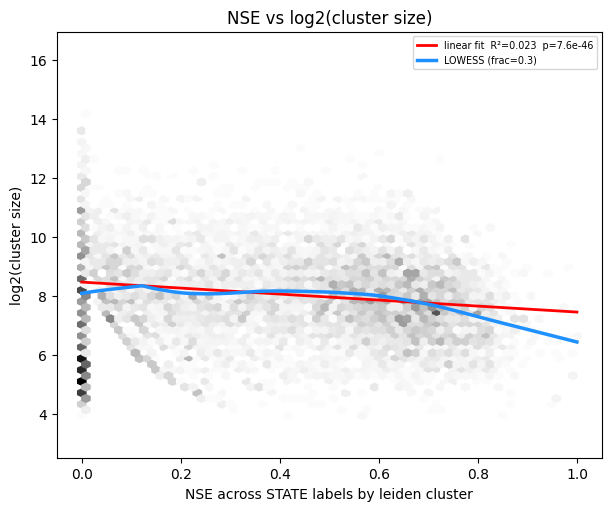

In [15]:
from statsmodels.nonparametric.smoothers_lowess import lowess

paired = xr.Dataset({
    "nse": ds.nse_leiden,
    "n_cells": ds.n_cells_leiden,
}).stack(point=("accession", "leiden_cluster")).dropna(dim="point")

x = paired["nse"].values
y = np.log2(paired["n_cells"].values.astype(float))

fig, ax = plt.subplots(1, 1, figsize=(6, 5), layout="constrained")

ax.hexbin(x, y, gridsize=60, cmap="Greys", mincnt=1)

regressor = stats.linregress(x=x, y=y)
xx = np.linspace(x.min(), x.max(), 300)
yy = regressor.intercept + regressor.slope * xx
ax.plot(xx, yy, color="red", lw=2,
        label=f"linear fit  R²={regressor.rvalue**2:.3f}  p={regressor.pvalue:.1e}")

smooth = lowess(y, x, frac=0.3, return_sorted=True)
ax.plot(smooth[:, 0], smooth[:, 1], color="dodgerblue", lw=2.5, label="LOWESS (frac=0.3)")

ax.set_xlabel("NSE across STATE labels by leiden cluster")
ax.set_ylabel("log2(cluster size)")
ax.set_title("NSE vs log2(cluster size)")
ax.legend(fontsize="x-small", loc="upper right")

print(f"global slope = {regressor.slope:.4f} ± {regressor.stderr:.4f} (SE),  R² = {regressor.rvalue**2:.4f},  p = {regressor.pvalue:.3e}")
plt.show()


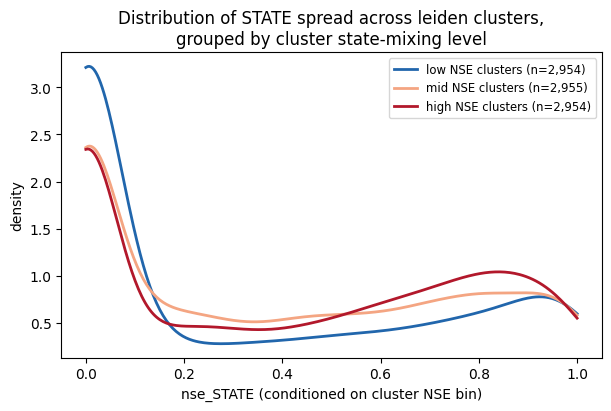

In [16]:
bin_names = ["low", "mid", "high"]

nse_vals = ds.nse_leiden.values
flat = nse_vals.ravel()
valid_mask = np.isfinite(flat)
codes = np.full(flat.shape, -1, dtype=np.int8)
codes[valid_mask] = pd.qcut(flat[valid_mask], q=len(bin_names), labels=False)
ds["nse_leiden_bin"] = xr.DataArray(
    codes.reshape(nse_vals.shape),
    coords=ds.nse_leiden.coords,
    dims=ds.nse_leiden.dims,
)

for bin_idx, name in enumerate(bin_names):
    mask = ds.nse_leiden_bin == bin_idx
    masked_counts = ds.cell_count.where(mask, 0)
    ds[f"nse_STATE_{name}"] = _normalized_entropy(masked_counts, dim="leiden_cluster")

palette = ["#2166ac", "#f4a582", "#b2182b"]

fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")

for bin_idx, (name, color) in enumerate(zip(bin_names, palette)):
    vals = ds[f"nse_STATE_{name}"].values.ravel()
    vals = vals[np.isfinite(vals)]
    n_clusters = int((ds.nse_leiden_bin == bin_idx).sum().item())
    if vals.size < 2:
        continue
    kde = stats.gaussian_kde(vals)
    xx = np.linspace(0, 1, 300)
    ax.plot(xx, kde(xx), color=color, lw=2, label=f"{name} NSE clusters (n={n_clusters:,})")

ax.set_xlabel("nse_STATE (conditioned on cluster NSE bin)")
ax.set_ylabel("density")
ax.set_title("Distribution of STATE spread across leiden clusters,\ngrouped by cluster state-mixing level")
ax.legend(fontsize="small")

### Cell-weighted mean cluster NSE per STATE

Leiden cluster labels are not aligned across accessions (cluster 3 in accession A is unrelated to cluster 3 in accession B), so the weighted mean must be computed independently within each accession before aggregating.

For each accession $a$ and cell type $s$:

$$\text{wmNSE}_{a,s} = \frac{\sum_{l} c_{a,s,l} \cdot \text{NSE}_{a,l}}{\sum_{l} c_{a,s,l}}$$

where $c_{a,s,l}$ is the cell count and $\text{NSE}_{a,l}$ is the normalized Shannon entropy of cluster $l$ across STATE labels, both specific to accession $a$. The per-state summary is the **median** of $\text{wmNSE}_{a,s}$ across accessions (restricted to accessions where state $s$ has at least one cell).

A low score means the cell type consistently ends up in clusters dominated by a single STATE. A high score means it tends to appear in clusters shared across many STATE labels.

In [17]:
counts = ds.cell_count.values        # (accession, STATE, leiden_cluster)
nse = ds.nse_leiden.values            # (accession, leiden_cluster)
accessions = ds.accession.values
states = ds.STATE.values

per_acc = []
for i, acc in enumerate(accessions):
    nse_row = nse[i]                  # (leiden_cluster,)
    for j, state in enumerate(states):
        if state == "":
            continue
        w = counts[i, j].astype(float)  # (leiden_cluster,)
        valid = np.isfinite(nse_row) & (w > 0)
        if valid.sum() == 0:
            continue
        per_acc.append({
            "accession": acc,
            "STATE": state,
            "wmNSE": np.average(nse_row[valid], weights=w[valid]),
        })

df_per_acc = pd.DataFrame(per_acc)

df_wmean = (
    df_per_acc.groupby("STATE")["wmNSE"]
    .median()
    .reset_index()
    .sort_values("wmNSE")
)
df_wmean

,STATE,wmNSE
19,lung multiciliated epithelial cell,0.198562
14,endothelial cell of lymphatic vessel,0.251143
16,fibroblast,0.294706
35,sebocyte,0.316562
17,hematopoietic precursor cell,0.353922
36,smooth muscle cell,0.370632
25,"naive thymus-derived CD4-positive, alpha-beta ...",0.385457
20,macrophage,0.410112
7,basophil,0.413484
21,mast cell,0.414332


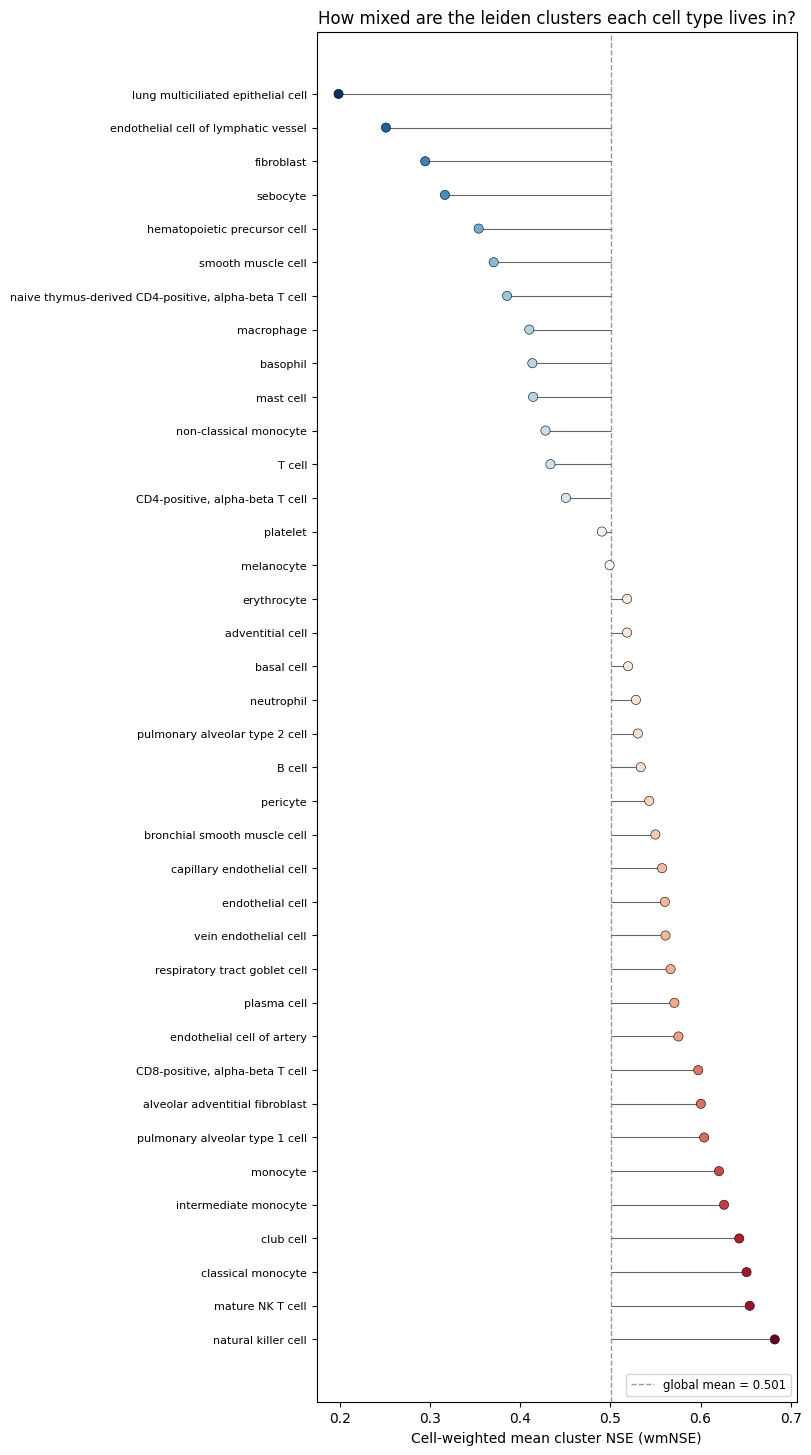

In [18]:
from matplotlib.colors import TwoSlopeNorm

states = df_wmean["STATE"].values
vals = df_wmean["wmNSE"].values
n_states = len(states)
global_mean = np.nanmean(vals)

fig, ax = plt.subplots(figsize=(8, max(6, n_states * 0.38)), layout="constrained")

y_pos = np.arange(n_states)
norm = TwoSlopeNorm(vmin=vals.min(), vcenter=global_mean, vmax=vals.max())

ax.axvline(global_mean, color="#999999", ls="--", lw=1, zorder=1,
           label=f"global mean = {global_mean:.3f}")
ax.hlines(y_pos, global_mean, vals, color="#666666", linewidth=0.8, zorder=2)
ax.scatter(vals, y_pos, c=vals, cmap="RdBu_r", norm=norm,
           s=44, zorder=3, edgecolors="black", linewidths=0.4)

ax.set_yticks(y_pos)
ax.set_yticklabels(states, fontsize=8)
ax.set_xlabel("Cell-weighted mean cluster NSE (wmNSE)")
ax.set_title("How mixed are the leiden clusters each cell type lives in?")
ax.legend(fontsize="small", loc="lower right")
ax.invert_yaxis()

In [19]:
ds

<xarray.Dataset> Size: 15MB
Dimensions:         (accession: 765, STATE: 39, leiden_cluster: 106)
Coordinates:
  * accession       (accession) <U11 34kB 'ERX11662338' ... 'SRX9927818'
  * STATE           (STATE) <U52 8kB '' 'B cell' ... 'vein endothelial cell'
  * leiden_cluster  (leiden_cluster) <U3 1kB '0' '1' '2' ... '103' '104' '105'
Data variables:
    cell_count      (accession, STATE, leiden_cluster) int32 13MB 1 0 0 ... 0 0
    n_cells_leiden  (accession, leiden_cluster) int64 649kB 3501 279 917 ... 0 0
    n_cells_STATE   (accession, STATE) int64 239kB 20 771 4796 375 0 ... 0 0 0 0
    nse_leiden      (accession, leiden_cluster) float64 649kB 0.03252 ... nan
    nse_STATE       (accession, STATE) float64 239kB 0.2864 0.626 ... nan nan
    nse_leiden_bin  (accession, leiden_cluster) int8 81kB 0 0 0 2 ... -1 -1 -1
    nse_STATE_low   (accession, STATE) float64 239kB 0.2864 0.3615 ... nan nan
    nse_STATE_mid   (accession, STATE) float64 239kB nan nan nan ... nan nan nan
    nse_STATE_high  (accession, STATE) float64 239kB nan 0.6624 ... nan nan

## V2: compute NSE by STATE by each quartile of leiden cluster NSE

In [20]:
nse_vals = ds.nse_leiden.values
flat = nse_vals.ravel()
valid_mask = np.isfinite(flat)
codes = np.full(flat.shape, -1, dtype=int)
codes[valid_mask] = pd.qcut(flat[valid_mask], q=3, labels=False)
bin_codes = xr.DataArray(
    codes.reshape(nse_vals.shape),
    coords=ds.nse_leiden.coords,
    dims=ds.nse_leiden.dims,
)

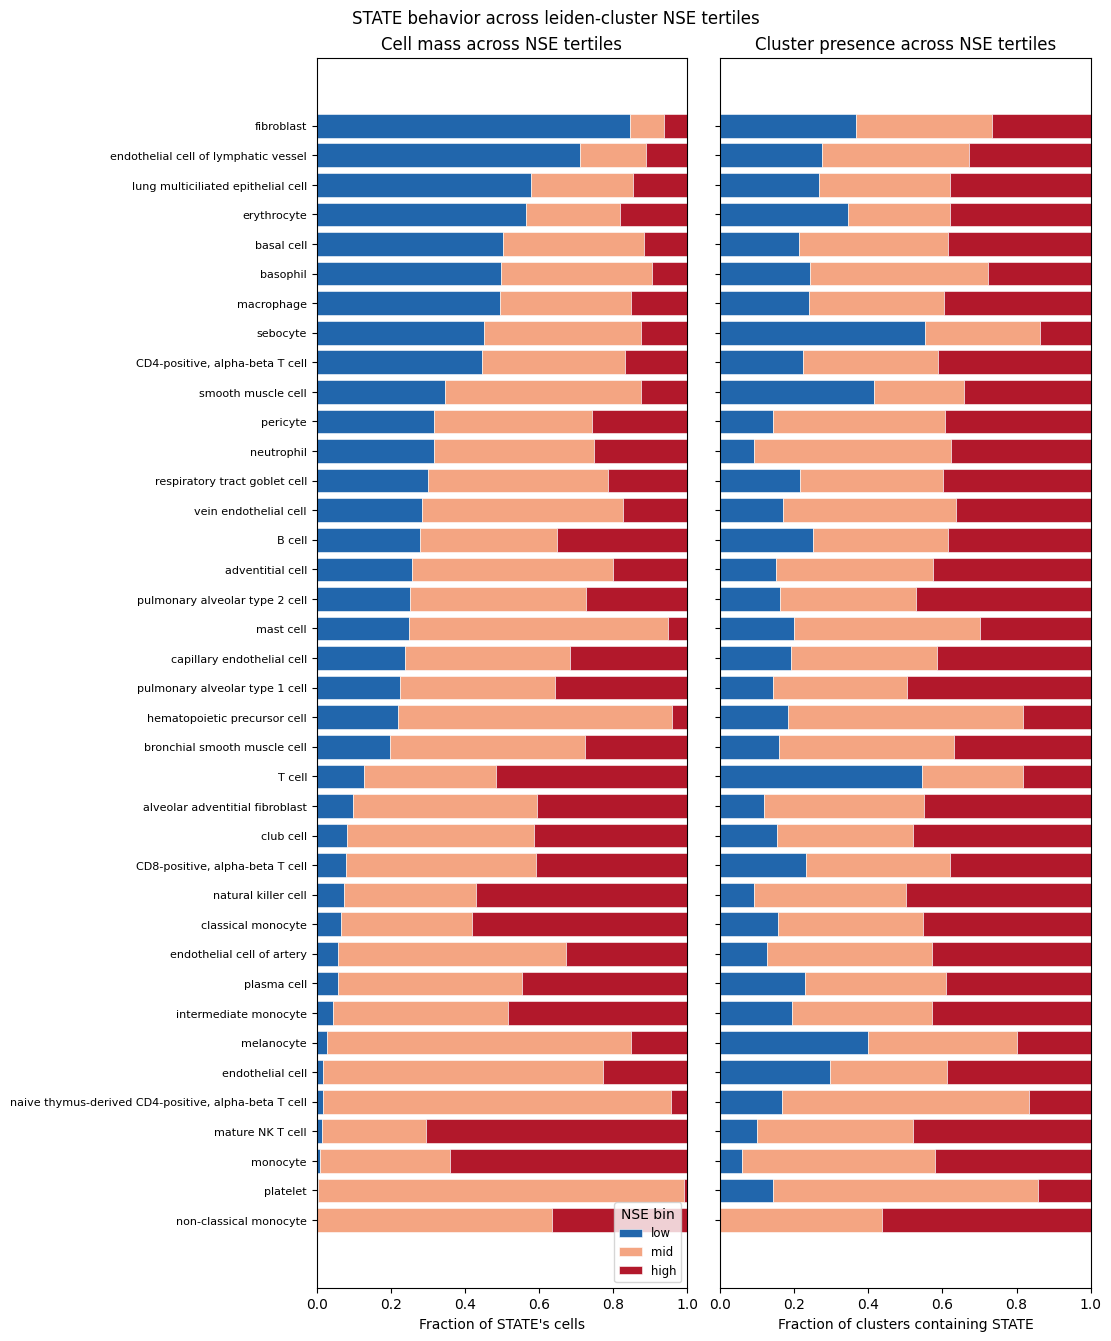

In [22]:
bin_names = ["low", "mid", "high"]
palette = ["#2166ac", "#f4a582", "#b2182b"]

cell_mass_per_bin = []
for bin_idx in range(len(bin_names)):
    mask = ds.nse_leiden_bin == bin_idx
    cells_in_bin = ds.cell_count.where(mask, 0).sum(dim=("accession", "leiden_cluster"))
    cell_mass_per_bin.append(cells_in_bin)
cell_mass = xr.concat(cell_mass_per_bin, dim=pd.Index(bin_names, name="bin"))
total_cells_per_state = ds.cell_count.sum(dim=("accession", "leiden_cluster"))
cell_share = (cell_mass / total_cells_per_state).fillna(0).to_pandas().T

has_state = ds.cell_count > 0
clusters_per_bin = []
for bin_idx in range(len(bin_names)):
    mask = ds.nse_leiden_bin == bin_idx
    present_in_bin = (has_state & mask).sum(dim=("accession", "leiden_cluster"))
    clusters_per_bin.append(present_in_bin)
cluster_counts = xr.concat(clusters_per_bin, dim=pd.Index(bin_names, name="bin"))
total_clusters_per_state = has_state.sum(dim=("accession", "leiden_cluster"))
cluster_share = (cluster_counts / total_clusters_per_state).fillna(0).to_pandas().T

cell_share = cell_share.loc[cell_share.index != ""]
cluster_share = cluster_share.loc[cluster_share.index != ""]
state_order = cell_share.sort_values("low", ascending=False).index.tolist()
cell_share = cell_share.loc[state_order]
cluster_share = cluster_share.loc[state_order]

n_states = len(state_order)
fig, (ax_cell, ax_clu) = plt.subplots(
    1, 2,
    figsize=(11, max(6, n_states * 0.35)),
    layout="constrained",
    sharey=True,
)
y_base = np.arange(n_states)

left = np.zeros(n_states)
for name, color in zip(bin_names, palette):
    ax_cell.barh(y_base, cell_share[name].values, left=left,
                 color=color, edgecolor="white", linewidth=0.4, label=name)
    left += cell_share[name].values
ax_cell.set_xlim(0, 1)
ax_cell.set_xlabel("Fraction of STATE's cells")
ax_cell.set_title("Cell mass across NSE tertiles")
ax_cell.legend(fontsize="small", loc="lower right", title="NSE bin")

left = np.zeros(n_states)
for name, color in zip(bin_names, palette):
    ax_clu.barh(y_base, cluster_share[name].values, left=left,
                color=color, edgecolor="white", linewidth=0.4)
    left += cluster_share[name].values
ax_clu.set_xlim(0, 1)
ax_clu.set_xlabel("Fraction of clusters containing STATE")
ax_clu.set_title("Cluster presence across NSE tertiles")

ax_cell.set_yticks(y_base)
ax_cell.set_yticklabels(state_order, fontsize=8)
ax_cell.invert_yaxis()

fig.suptitle("STATE behavior across leiden-cluster NSE tertiles", fontsize=12)
plt.show()